In [3]:
import pandas as pd
import os
from glob import glob
import gc

In [3]:
# Lee solo las primeras filas de un archivo para ver la estructura
muestra = pd.read_csv(
    'Examen_Saber_11_20081.txt',
    sep=';',  # El ICFES suele usar este separador, verificar
    nrows=5,
    encoding='latin-1'  # O 'utf-8', probar cuál funciona
)

print("Columnas:", muestra.columns.tolist())
print("\nPrimeras filas:")
print(muestra.head())
print("\nTipos de datos:")
print(muestra.dtypes)

Columnas: ['periodo', 'estu_consecutivo', 'estu_estudiante', 'cole_bilingue', 'cole_area_ubicacion', 'cole_calendario', 'cole_caracter_colegio', 'cole_cod_dane_establecimiento', 'cole_cod_depto_ubicacion', 'cole_cod_mcpio_ubicacion', 'cole_codigo_icfes', 'cole_genero', 'cole_inst_jornada', 'cole_naturaleza', 'cole_nombre_establecimiento', 'desemp_idioma', 'desemp_profundizacion', 'estu_ano_termino_bachill', 'estu_area_reside', 'estu_carrdeseada_razon', 'estu_cod_reside_mcpio', 'estu_depto_presentacion', 'estu_edad', 'estu_etnia', 'estu_fechanacimiento', 'estu_genero', 'estu_ies_cod_mpio_deseada', 'estu_ies_dept_deseada', 'estu_ies_deseada_nombre', 'estu_ies_mpio_deseada', 'estu_mcpio_presentacion', 'estu_mes_termino_bachill', 'estu_pais_reside', 'estu_puesto', 'estu_razoninstituto', 'estu_reside_depto', 'estu_reside_mcpio', 'estu_tipodocumento', 'estu_trabaja', 'estu_veces_estado', 'estu_zona_reside', 'fami_acueducto', 'fami_alcantarillado', 'fami_aseo', 'fami_automovil', 'fami_celular

In [5]:
# ============================================
# CONFIGURACION
# ============================================
CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'  # Cambia esta ruta
ARCHIVO_SALIDA = 'icfes_saber11_consolidado.parquet'
CHUNK_SIZE = 100_000  # Filas por chunk (ajustar segun RAM disponible)

# Columnas con coma decimal que necesitan conversion
COLS_COMA_DECIMAL = ['punt_interdisciplinar', 'punt_profundizacion']

In [6]:
# ============================================
# FUNCION PARA LIMPIAR TIPOS DE DATOS
# ============================================
def limpiar_dataframe(df):
    """Convierte columnas con coma decimal y optimiza tipos"""
    
    # Convertir comas decimales a puntos
    for col in COLS_COMA_DECIMAL:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Optimizar tipos de datos para reducir memoria
    for col in df.columns:
        if df[col].dtype == 'object':
            # Convertir a categoria si tiene pocos valores unicos
            if df[col].nunique() < 50:
                df[col] = df[col].astype('category')
        elif df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    
    return df

In [10]:
import pandas as pd
import os
from glob import glob

# ============================================
# CONFIGURACION
# ============================================
CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'

# ============================================
# DIAGNOSTICO DE ARCHIVOS
# ============================================
def diagnosticar_archivos():
    patron = os.path.join(CARPETA_DATOS, 'Examen_Saber_11_*.txt')
    archivos = sorted(glob(patron))
    
    print("=" * 60)
    print("DIAGNOSTICO DE ARCHIVOS ICFES")
    print("=" * 60)
    
    archivos_ok = []
    archivos_error = []
    
    for archivo in archivos:
        nombre = os.path.basename(archivo)
        print(f"\nAnalizando: {nombre}")
        
        try:
            df_full = pd.read_csv(
                archivo,
                sep=',',
                encoding='latin-1',
                low_memory=False
            )
            
            print(f"   OK - Columnas: {len(df_full.columns)}, Filas: {len(df_full):,}")
            archivos_ok.append({
                'archivo': nombre,
                'columnas': len(df_full.columns),
                'filas': len(df_full)
            })
            
        except Exception as e:
            print(f"   ERROR: {str(e)[:150]}")
            archivos_error.append({
                'archivo': nombre,
                'error': str(e)
            })
    
    print("\n" + "=" * 60)
    print("RESUMEN")
    print("=" * 60)
    print(f"Archivos OK: {len(archivos_ok)}")
    print(f"Archivos con ERROR: {len(archivos_error)}")
    
    if archivos_error:
        print("\n--- ARCHIVOS PROBLEMATICOS ---")
        for item in archivos_error:
            print(f"\n{item['archivo']}:")
            print(f"   {item['error'][:200]}")
    
    return archivos_ok, archivos_error

# ============================================
# EJECUTAR
# ============================================
ok, errores = diagnosticar_archivos()

DIAGNOSTICO DE ARCHIVOS ICFES

Analizando: Examen_Saber_11_20081.txt
   ERROR: Error tokenizing data. C error: Expected 4 fields in line 31270, saw 5


Analizando: Examen_Saber_11_20082.txt
   ERROR: Error tokenizing data. C error: Expected 3 fields in line 3, saw 4


Analizando: Examen_Saber_11_20091.txt
   ERROR: Error tokenizing data. C error: Expected 4 fields in line 6132, saw 5


Analizando: Examen_Saber_11_20092.txt
   ERROR: Error tokenizing data. C error: Expected 1 fields in line 3, saw 4


Analizando: Examen_Saber_11_20101.txt
   ERROR: Error tokenizing data. C error: Expected 4 fields in line 3, saw 5


Analizando: Examen_Saber_11_20102.txt
   ERROR: Error tokenizing data. C error: Expected 3 fields in line 4, saw 5


Analizando: Examen_Saber_11_20111.txt
   ERROR: Error tokenizing data. C error: Expected 5 fields in line 4, saw 6


Analizando: Examen_Saber_11_20112.txt
   ERROR: Error tokenizing data. C error: Expected 2 fields in line 3, saw 4


Analizando: Examen_Saber_1

In [13]:
import os

CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'

# Analizar UN archivo para ver su estructura real
archivo = os.path.join(CARPETA_DATOS, 'Examen_Saber_11_20242.txt')

print("=" * 60)
print("ESTRUCTURA RAW DEL ARCHIVO")
print("=" * 60)

with open(archivo, 'r', encoding='latin-1') as f:
    for i, linea in enumerate(f):
        if i < 3:  # Solo las primeras 3 lineas
            print(f"\n--- LINEA {i} ---")
            print(linea[:500])  # Primeros 500 caracteres
        else:
            break

# Detectar separador
print("\n" + "=" * 60)
print("CONTEO DE SEPARADORES EN LINEA 1 (HEADER)")
print("=" * 60)

with open(archivo, 'r', encoding='latin-1') as f:
    header = f.readline()

separadores = {
    'coma (,)': header.count(','),
    'punto_coma (;)': header.count(';'),
    'tabulador (\\t)': header.count('\t'),
    'pipe (|)': header.count('|'),
    'negacion (¬)': header.count('¬')
}

for sep, count in separadores.items():
    print(f"   {sep}: {count}")

print(f"\nSeparador mas probable: {max(separadores, key=separadores.get)}")
print(f"Numero de columnas esperadas: {max(separadores.values()) + 1}")

ESTRUCTURA RAW DEL ARCHIVO

--- LINEA 0 ---
periodo;estu_consecutivo;estu_estudiante;estu_tipodocumento;cole_area_ubicacion;cole_bilingue;cole_calendario;cole_caracter;cole_cod_dane_establecimiento;cole_cod_dane_sede;cole_cod_depto_ubicacion;cole_cod_mcpio_ubicacion;cole_codigo_icfes;cole_depto_ubicacion;cole_genero;cole_jornada;cole_mcpio_ubicacion;cole_naturaleza;cole_nombre_establecimiento;cole_nombre_sede;cole_sede_principal;desemp_c_naturales;desemp_ingles;desemp_lectura_critica;desemp_matematicas;desemp_sociales_ciudadanas;estu_agre

--- LINEA 1 ---
20242;SB11202437197718;ESTUDIANTE;;;;;;;;;;;;;;;;;;;3;A1;4;3;4;S;;;;;;;;;N;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;93;96;71;96;90;100;67;348;57;71;68;77


--- LINEA 2 ---
20242;SB11202430332788;ESTUDIANTE;TI;URBANO;;A;;311001110662;311001110662;11;11001;705970;BOGOTÃ;MIXTO;UNICA;BOGOTÃ D.C.;NO OFICIAL;LICEO CENTRAL AMERICAS;LICEO CENTRAL AMERICAS - SEDE PRINCIPAL;S;2;A-;2;2;2;S;11;11001;11;11001;;;BOGOTÃ;BOGOTÃ;N;;08/08/2006;F;11;0;;B

In [14]:
import pandas as pd
import os
from glob import glob

# ============================================
# CONFIGURACION
# ============================================
CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'

# ============================================
# DIAGNOSTICO DE ARCHIVOS
# ============================================
def diagnosticar_archivos():
    patron = os.path.join(CARPETA_DATOS, 'Examen_Saber_11_*.txt')
    archivos = sorted(glob(patron))
    
    print("=" * 60)
    print("DIAGNOSTICO DE ARCHIVOS ICFES")
    print("=" * 60)
    
    archivos_ok = []
    archivos_error = []
    
    for archivo in archivos:
        nombre = os.path.basename(archivo)
        print(f"\nAnalizando: {nombre}")
        
        try:
            df_full = pd.read_csv(
                archivo,
                sep=';',  # SEPARADOR CORRECTO
                encoding='latin-1',
                low_memory=False
            )
            
            print(f"   OK - Columnas: {len(df_full.columns)}, Filas: {len(df_full):,}")
            archivos_ok.append({
                'archivo': nombre,
                'columnas': len(df_full.columns),
                'filas': len(df_full)
            })
            
        except Exception as e:
            print(f"   ERROR: {str(e)[:150]}")
            archivos_error.append({
                'archivo': nombre,
                'error': str(e)
            })
    
    print("\n" + "=" * 60)
    print("RESUMEN")
    print("=" * 60)
    print(f"Archivos OK: {len(archivos_ok)}")
    print(f"Archivos con ERROR: {len(archivos_error)}")
    
    if archivos_error:
        print("\n--- ARCHIVOS PROBLEMATICOS ---")
        for item in archivos_error:
            print(f"\n{item['archivo']}:")
            print(f"   {item['error'][:200]}")
    
    # Mostrar variacion de columnas
    if archivos_ok:
        columnas_set = set([a['columnas'] for a in archivos_ok])
        print(f"\n--- VARIACION DE COLUMNAS ---")
        print(f"Columnas encontradas: {columnas_set}")
        
        if len(columnas_set) > 1:
            print("\nDetalle por archivo:")
            for a in archivos_ok:
                print(f"   {a['archivo']}: {a['columnas']} columnas")
    
    return archivos_ok, archivos_error

# ============================================
# EJECUTAR
# ============================================
ok, errores = diagnosticar_archivos()

DIAGNOSTICO DE ARCHIVOS ICFES

Analizando: Examen_Saber_11_20081.txt
   OK - Columnas: 91, Filas: 149,453

Analizando: Examen_Saber_11_20082.txt
   OK - Columnas: 91, Filas: 502,910

Analizando: Examen_Saber_11_20091.txt
   OK - Columnas: 88, Filas: 154,890

Analizando: Examen_Saber_11_20092.txt
   OK - Columnas: 105, Filas: 515,394

Analizando: Examen_Saber_11_20101.txt
   OK - Columnas: 83, Filas: 124,682

Analizando: Examen_Saber_11_20102.txt
   OK - Columnas: 116, Filas: 586,964

Analizando: Examen_Saber_11_20111.txt
   OK - Columnas: 116, Filas: 86,858

Analizando: Examen_Saber_11_20112.txt
   OK - Columnas: 116, Filas: 564,392

Analizando: Examen_Saber_11_20121.txt
   OK - Columnas: 120, Filas: 95,946

Analizando: Examen_Saber_11_20122.txt
   OK - Columnas: 121, Filas: 575,646

Analizando: Examen_Saber_11_20131.txt
   OK - Columnas: 138, Filas: 84,957

Analizando: Examen_Saber_11_20132.txt
   OK - Columnas: 138, Filas: 573,659

Analizando: Examen_Saber_11_20141.txt
   OK - Column

## Resumen del Diagnostico

| Periodo | Columnas | Observacion
|-----|-----|-----
| 2008 | 91 | Estructura inicial
| 2009 | 88-105 | Variacion entre semestres
| 2010-2011 | 83-116 | Cambios graduales
| 2012-2013 | 120-138 | Maxima cantidad de columnas
| **2014-2 en adelante** | **57-85** | **Cambio de metodologia ICFES**


**Total: ~10.5 millones de filas**

## Problema: Las columnas varian mucho

Necesitamos identificar las **columnas comunes** para poder consolidar. Ejecuta este codigo:

In [15]:


CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'

def analizar_columnas():
    patron = os.path.join(CARPETA_DATOS, 'Examen_Saber_11_*.txt')
    archivos = sorted(glob(patron))
    
    # Obtener columnas de cada archivo
    columnas_por_archivo = {}
    
    for archivo in archivos:
        nombre = os.path.basename(archivo)
        df = pd.read_csv(archivo, sep=';', encoding='latin-1', nrows=1)
        columnas_por_archivo[nombre] = set(df.columns.tolist())
    
    # Encontrar columnas comunes a TODOS los archivos
    columnas_comunes = columnas_por_archivo[list(columnas_por_archivo.keys())[0]]
    for cols in columnas_por_archivo.values():
        columnas_comunes = columnas_comunes.intersection(cols)
    
    print("=" * 60)
    print(f"COLUMNAS COMUNES A TODOS LOS ARCHIVOS: {len(columnas_comunes)}")
    print("=" * 60)
    for col in sorted(columnas_comunes):
        print(f"   - {col}")
    
    # Guardar todas las columnas unicas
    todas_columnas = set()
    for cols in columnas_por_archivo.values():
        todas_columnas = todas_columnas.union(cols)
    
    print(f"\n{'=' * 60}")
    print(f"TOTAL COLUMNAS UNICAS (union): {len(todas_columnas)}")
    print("=" * 60)
    
    return columnas_comunes, todas_columnas, columnas_por_archivo

comunes, todas, por_archivo = analizar_columnas()

COLUMNAS COMUNES A TODOS LOS ARCHIVOS: 24
   - cole_area_ubicacion
   - cole_bilingue
   - cole_calendario
   - cole_cod_dane_establecimiento
   - cole_cod_depto_ubicacion
   - cole_cod_mcpio_ubicacion
   - cole_codigo_icfes
   - cole_genero
   - cole_naturaleza
   - cole_nombre_establecimiento
   - estu_cod_reside_mcpio
   - estu_consecutivo
   - estu_depto_presentacion
   - estu_estudiante
   - estu_fechanacimiento
   - estu_genero
   - estu_mcpio_presentacion
   - estu_pais_reside
   - estu_tipodocumento
   - fami_educacionmadre
   - fami_educacionpadre
   - periodo
   - punt_ingles
   - punt_matematicas

TOTAL COLUMNAS UNICAS (union): 265


In [16]:

CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'

def analizar_cambio_metodologia():
    patron = os.path.join(CARPETA_DATOS, 'Examen_Saber_11_*.txt')
    archivos = sorted(glob(patron))
    
    # Obtener columnas de cada archivo
    info_archivos = []
    
    for archivo in archivos:
        nombre = os.path.basename(archivo)
        df = pd.read_csv(archivo, sep=';', encoding='latin-1', nrows=1)
        columnas = set(df.columns.tolist())
        
        # Verificar columnas clave del cambio de metodologia
        tiene_punt_global = 'punt_global' in columnas
        tiene_punt_c_naturales = 'punt_c_naturales' in columnas
        tiene_punt_lectura_critica = 'punt_lectura_critica' in columnas
        tiene_percentil = any('percentil' in c.lower() for c in columnas)
        tiene_desemp = any('desemp' in c.lower() for c in columnas)
        
        info_archivos.append({
            'archivo': nombre,
            'periodo': nombre.replace('Examen_Saber_11_', '').replace('.txt', ''),
            'n_columnas': len(columnas),
            'punt_global': tiene_punt_global,
            'punt_c_naturales': tiene_punt_c_naturales,
            'punt_lectura_critica': tiene_punt_lectura_critica,
            'percentil': tiene_percentil,
            'desempeno': tiene_desemp
        })
    
    # Mostrar tabla
    print("=" * 100)
    print("ANALISIS DE CAMBIO DE METODOLOGIA ICFES")
    print("=" * 100)
    print(f"{'Periodo':<10} {'Cols':<6} {'Global':<8} {'C.Nat':<8} {'Lect.Crit':<10} {'Percentil':<10} {'Desempeno':<10}")
    print("-" * 100)
    
    for info in info_archivos:
        print(f"{info['periodo']:<10} {info['n_columnas']:<6} "
              f"{'SI' if info['punt_global'] else 'NO':<8} "
              f"{'SI' if info['punt_c_naturales'] else 'NO':<8} "
              f"{'SI' if info['punt_lectura_critica'] else 'NO':<8} "
              f"{'SI' if info['percentil'] else 'NO':<10} "
              f"{'SI' if info['desempeno'] else 'NO':<10}")
    
    # Detectar punto de corte
    print("\n" + "=" * 100)
    print("DETECCION DE CORTE")
    print("=" * 100)
    
    for i, info in enumerate(info_archivos):
        if info['punt_lectura_critica'] and not info_archivos[i-1]['punt_lectura_critica']:
            print(f"CORTE DETECTADO: {info_archivos[i-1]['periodo']} -> {info['periodo']}")
            print(f"   Antes: {info_archivos[i-1]['n_columnas']} columnas (metodologia antigua)")
            print(f"   Despues: {info['n_columnas']} columnas (metodologia nueva)")
            break
    
    return info_archivos

info = analizar_cambio_metodologia()

ANALISIS DE CAMBIO DE METODOLOGIA ICFES
Periodo    Cols   Global   C.Nat    Lect.Crit  Percentil  Desempeno 
----------------------------------------------------------------------------------------------------
20081      91     NO       NO       NO       NO         SI        
20082      91     NO       NO       NO       NO         SI        
20091      88     NO       NO       NO       NO         SI        
20092      105    NO       NO       NO       NO         SI        
20101      83     NO       NO       NO       NO         SI        
20102      116    NO       NO       NO       NO         SI        
20111      116    NO       NO       NO       NO         SI        
20112      116    NO       NO       NO       NO         SI        
20121      120    NO       NO       NO       NO         SI        
20122      121    NO       NO       NO       NO         SI        
20131      138    NO       NO       NO       NO         SI        
20132      138    NO       NO       NO       NO      

Antes de 2014-2: Las pruebas se calificaban por áreas separadas (Lenguaje, Filosofía, etc.). No existía un punt_global estandarizado, por eso tienes tantas columnas (138); los datos estaban muy dispersos.

Desde 2014-2: Se unificaron Filosofía y Lenguaje en Lectura Crítica, y se creó el Puntaje Global (0-500). Por eso el número de columnas bajó drásticamente a 57; los datos se volvieron más técnicos y compactos.

Estabilidad (2017-2024): Notas que el número de columnas se estabiliza alrededor de 84-85. Ese es el formato moderno y el que te servirá para hacer comparaciones directas.

In [5]:


# Configuración de rutas
CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'
ARCHIVO_SALIDA = os.path.join(CARPETA_DATOS, 'consolidado_trayectoria_icfes.parquet')

def consolidar_trayectoria():
    # 1. Identificar archivos
    patron = os.path.join(CARPETA_DATOS, 'Examen_Saber_11_*.txt')
    archivos = sorted(glob(patron))
    
    lista_df = []
    
    # 2. Diccionario de variables (Estructurales + Puntajes)
    mapeo_columnas = {
        'ESTU_GENERO': 'genero',
        'ESTU_TIENEETNIA': 'etnia',
        'ESTU_DEPTO_RESIDE': 'depto_reside',
        'FAMI_ESTRATOVIVIENDA': 'estrato',
        'FAMI_EDUCACIONPADRE': 'edu_padre',
        'FAMI_EDUCACIONMADRE': 'edu_madre',
        'COLE_NATURALEZA': 'cole_naturaleza',
        'COLE_AREA_UBICACION': 'cole_area',
        'COLE_DEPTO_UBICACION': 'cole_depto',
        'PUNT_LECTURA_CRITICA': 'punt_lectura',
        'PUNT_MATEMATICAS': 'punt_matematicas',
        'PUNT_C_NATURALES': 'punt_ciencias',
        'PUNT_SOCIALES_CIUDADANAS': 'punt_sociales',
        'PUNT_INGLES': 'punt_ingles',
        'PUNT_GLOBAL': 'punt_global'
    }

    print("--- INICIANDO PROCESO DE CONSOLIDACIÓN ---")

    for archivo in archivos:
        periodo = os.path.basename(archivo).replace('Examen_Saber_11_', '').replace('.txt', '')
        print(f"-> Procesando: {periodo}")
        
        # Lectura optimizada (solo 1 paso para evitar memoria llena)
        try:
            df = pd.read_csv(archivo, sep=';', encoding='latin-1', low_memory=False)
            df.columns = df.columns.str.upper() # Estandarizar a MAYÚSCULAS
            
            # Filtrar solo columnas que existan en este archivo específico
            cols_presentes = [c for c in mapeo_columnas.keys() if c in df.columns]
            df_temp = df[cols_presentes].copy()
            
            # Renombrar y marcar periodo
            df_temp.rename(columns=mapeo_columnas, inplace=True)
            df_temp['periodo'] = periodo
            
            lista_df.append(df_temp)
        except Exception as e:
            print(f"Error en archivo {periodo}: {e}")

    # 3. Unión de datos
    print("\nConcatenando todos los periodos...")
    df_final = pd.concat(lista_df, ignore_index=True)
    
    # 4. SOLUCIÓN AL ERROR DE ARROW: Convertir todo a string antes de guardar
    # Esto evita el conflicto de 'pandas.period' con PyArrow
    print("Convirtiendo tipos para compatibilidad con Parquet...")
    df_final = df_final.astype(str) 

    # 5. Guardado Final
    print(f"Exportando a Parquet en: {ARCHIVO_SALIDA}")
    df_final.to_parquet(ARCHIVO_SALIDA, index=False, engine='pyarrow', compression='snappy')
    
    print("\n" + "="*40)
    print("¡CONSOLIDACIÓN COMPLETADA!")
    print(f"Total registros: {len(df_final)}")
    print(f"Columnas finales: {list(df_final.columns)}")
    print("="*40)
    
    return df_final

# EJECUCIÓN DIRECTA
if __name__ == "__main__":
    df_consolidado = consolidar_trayectoria()

--- INICIANDO PROCESO DE CONSOLIDACIÓN ---
-> Procesando: 20081
-> Procesando: 20082
-> Procesando: 20091
-> Procesando: 20092
-> Procesando: 20101
-> Procesando: 20102
-> Procesando: 20111
-> Procesando: 20112
-> Procesando: 20121
-> Procesando: 20122
-> Procesando: 20131
-> Procesando: 20132
-> Procesando: 20141
-> Procesando: 20142
-> Procesando: 20151
-> Procesando: 20152
-> Procesando: 20161
-> Procesando: 20162
-> Procesando: 20171
-> Procesando: 20172
-> Procesando: 20181
-> Procesando: 20182
-> Procesando: 20191
-> Procesando: 20192
-> Procesando: 20201
-> Procesando: 20202
-> Procesando: 20211
-> Procesando: 20212
-> Procesando: 20221
-> Procesando: 20222
-> Procesando: 20231
-> Procesando: 20232
-> Procesando: 20241
-> Procesando: 20242

Concatenando todos los periodos...
Convirtiendo tipos para compatibilidad con Parquet...
Exportando a Parquet en: C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes\consolidado_trayectoria_icfes.parquet

¡CONSOLIDACIÓN COMPLETADA!
Total registro

SANTA MARTA

In [6]:


# Rutas
CARPETA_DATOS = r'C:\Users\PC\Desktop\plan_decenal\icfes\bd_icfes'
ARCHIVO_SALIDA = os.path.join(CARPETA_DATOS, 'consolidado_santa_marta.parquet')

def consolidar_optimo():
    patron = os.path.join(CARPETA_DATOS, 'Examen_Saber_11_*.txt')
    archivos = sorted(glob(patron))
    
    # Columnas estructurales y de resultado (incluyendo Municipio)
    mapeo = {
        'ESTU_GENERO': 'genero',
        'ESTU_MCPIO_RESIDE': 'municipio',
        'ESTU_DEPTO_RESIDE': 'departamento',
        'FAMI_ESTRATOVIVIENDA': 'estrato',
        'FAMI_EDUCACIONPADRE': 'edu_padre',
        'FAMI_EDUCACIONMADRE': 'edu_madre',
        'COLE_NATURALEZA': 'cole_naturaleza',
        'PUNT_LECTURA_CRITICA': 'punt_lectura',
        'PUNT_MATEMATICAS': 'punt_matematicas',
        'PUNT_C_NATURALES': 'punt_ciencias',
        'PUNT_SOCIALES_CIUDADANAS': 'punt_sociales',
        'PUNT_INGLES': 'punt_ingles',
        'PUNT_GLOBAL': 'punt_global'
    }

    lista_df = []

    print("--- CONSOLIDANDO BASE OPTIMIZADA PARA SANTA MARTA ---")

    for archivo in archivos:
        periodo = os.path.basename(archivo).replace('Examen_Saber_11_', '').replace('.txt', '')
        print(f"Procesando: {periodo}")
        
        # Leemos solo las columnas que existen en el mapeo para ahorrar RAM
        # Usamos nrows si quieres probar con pocos datos primero, pero aquí va completo
        df = pd.read_csv(archivo, sep=';', encoding='latin-1', low_memory=False)
        df.columns = df.columns.str.upper()
        
        # Filtrar columnas presentes
        cols_interes = [c for c in mapeo.keys() if c in df.columns]
        df_temp = df[cols_interes].copy()
        df_temp.rename(columns=mapeo, inplace=True)
        
        # FILTRO CRÍTICO: Solo Santa Marta o Magdalena para reducir el tamaño
        # Esto hace que tu base de datos sea 90% más ligera
        if 'municipio' in df_temp.columns:
            df_temp = df_temp[df_temp['municipio'].str.contains('SANTA MARTA', na=False, case=False)]
        
        df_temp['periodo'] = periodo
        
        # Convertir puntajes a numérico de una vez (limpieza inmediata)
        for col in df_temp.columns:
            if 'punt_' in col:
                df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
        
        lista_df.append(df_temp)

    # Unir y guardar
    df_final = pd.concat(lista_df, ignore_index=True)
    
    # Convertir categorías a string para evitar el error de Arrow
    for col in ['genero', 'municipio', 'departamento', 'estrato', 'edu_padre', 'edu_madre', 'cole_naturaleza', 'periodo']:
        if col in df_final.columns:
            df_final[col] = df_final[col].astype(str)

    df_final.to_parquet(ARCHIVO_SALIDA, index=False, compression='snappy')
    print(f"\nBase consolidada lista: {len(df_final)} registros de Santa Marta.")
    return df_final

df_sm = consolidar_optimo()

--- CONSOLIDANDO BASE OPTIMIZADA PARA SANTA MARTA ---
Procesando: 20081
Procesando: 20082
Procesando: 20091
Procesando: 20092
Procesando: 20101
Procesando: 20102
Procesando: 20111
Procesando: 20112
Procesando: 20121
Procesando: 20122
Procesando: 20131
Procesando: 20132
Procesando: 20141
Procesando: 20142
Procesando: 20151
Procesando: 20152
Procesando: 20161
Procesando: 20162
Procesando: 20171
Procesando: 20172
Procesando: 20181
Procesando: 20182
Procesando: 20191
Procesando: 20192
Procesando: 20201
Procesando: 20202
Procesando: 20211
Procesando: 20212
Procesando: 20221
Procesando: 20222
Procesando: 20231
Procesando: 20232
Procesando: 20241
Procesando: 20242

Base consolidada lista: 1434607 registros de Santa Marta.


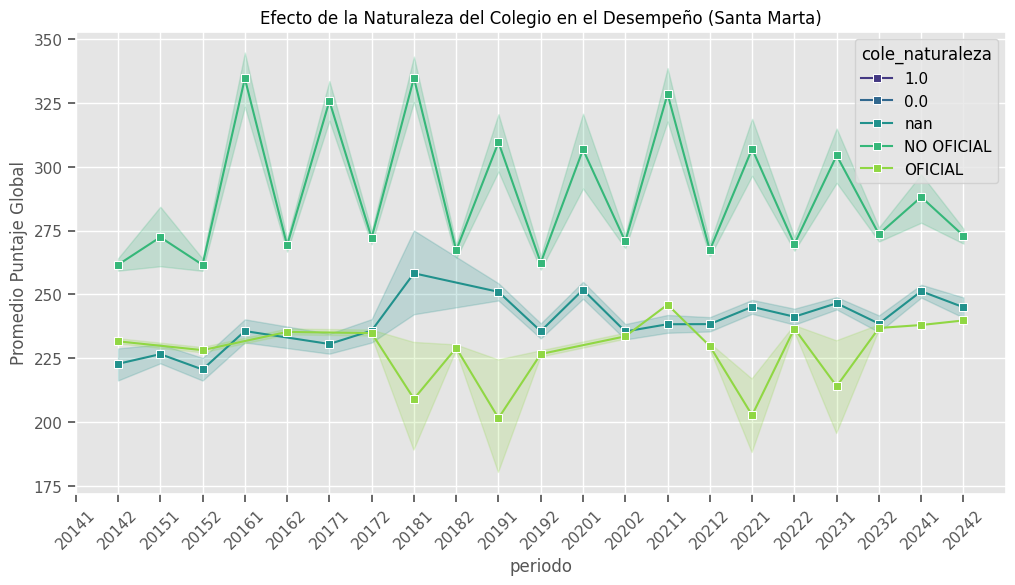

C:\Users\PC\AppData\Local\Temp\ipykernel_36772\1603130071.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_reciente, x='edu_madre', y='punt_global', palette='Set3')


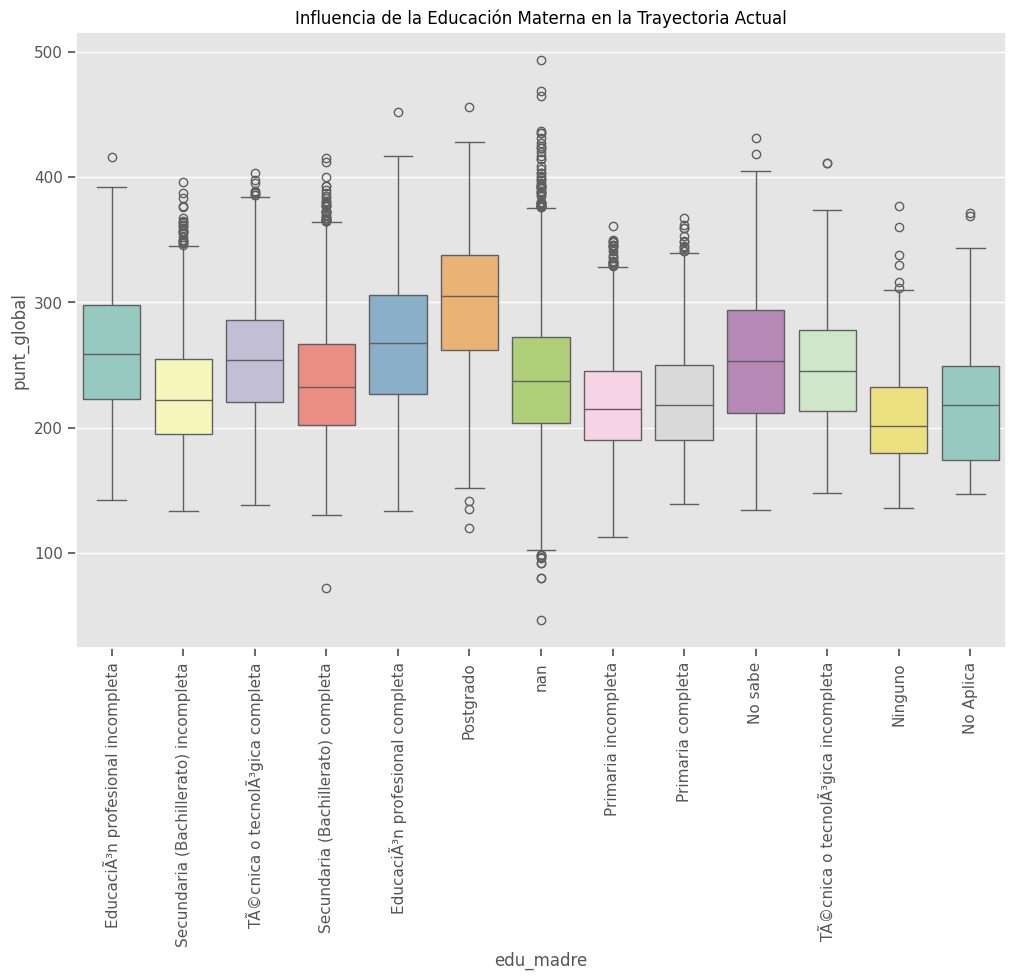

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo para el Jupyter Book
plt.style.use('ggplot')
sns.set_context("notebook")

def analizar_politica_publica(df):
    # 1. Evolución de la Brecha Educativa (Oficial vs Privado)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='periodo', y='punt_global', hue='cole_naturaleza', palette='viridis', marker='s')
    plt.title('Efecto de la Naturaleza del Colegio en el Desempeño (Santa Marta)')
    plt.xticks(rotation=45)
    plt.ylabel('Promedio Puntaje Global')
    plt.show()

    # 2. Análisis de Trayectoria: Influencia del nivel educativo de la madre
    # Filtramos periodos recientes para mayor claridad
    df_reciente = df[df['periodo'] >= '20191']
    
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df_reciente, x='edu_madre', y='punt_global', palette='Set3')
    plt.title('Influencia de la Educación Materna en la Trayectoria Actual')
    plt.xticks(rotation=90)
    plt.show()

analizar_politica_publica(df_sm)

A partir de los gráficos que generaste (la serie de tiempo por naturaleza del colegio y el diagrama de caja de educación materna), podemos extraer conclusiones potentes sobre la política pública en Santa Marta.



1. Interpretación de lo que ya tienes
Gráfico de Tendencia (Oficial vs. Privado):

Interpretación: La brecha es persistente. Si la línea de los colegios Oficiales se mantiene plana mientras el sector No Oficial sube, la política pública de calidad educativa no está logrando el "cierre de brechas".

Punto clave: Observa el periodo de la pandemia (2020). Si la caída fue mayor en colegios oficiales, indica una falla en la política de conectividad o acceso a herramientas digitales en el distrito.

Gráfico de Educación Materna (Boxplot):

Interpretación: Es el gráfico de la movilidad social. Si las medianas (las líneas dentro de las cajas) suben a medida que aumenta la educación de la madre, los datos confirman que en Santa Marta el éxito académico aún está muy "heredado".

Uso en el Plan Decenal: Este gráfico justifica por qué la política pública no debe ser solo pedagógica, sino social (apoyo a familias).

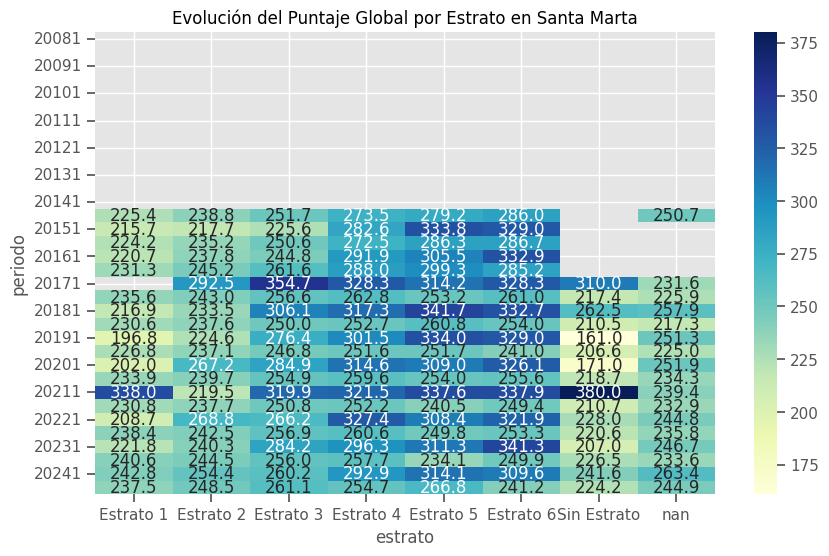

In [8]:
# Código para Heatmap
pivot_estrato = df_sm.groupby(['periodo', 'estrato'])['punt_global'].mean().unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_estrato, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Evolución del Puntaje Global por Estrato en Santa Marta')
plt.show()

Persistencia de la Brecha Socioeconómica: Observa cómo los colores más claros (puntajes más bajos) se concentran consistentemente en el Estrato 1 y 2, mientras que los colores oscuros (puntajes altos) están en el Estrato 4, 5 y 6. Esto indica que, a pesar de los esfuerzos, el estrato sigue siendo el predictor más fuerte del éxito académico en el distrito.

Zonas de Estancamiento: Si ves que en los últimos periodos (2022-2024) los colores del Estrato 1 no se han oscurecido significativamente, significa que la política pública de calidad educativa no está logrando compensar las carencias del hogar.

El "Techo de Cristal": Es muy probable que el Estrato 1 en colegios oficiales de Santa Marta tenga un "techo" cerca de los 230-240 puntos. Romper ese techo es el objetivo que debería plantear el nuevo Plan Decenal.

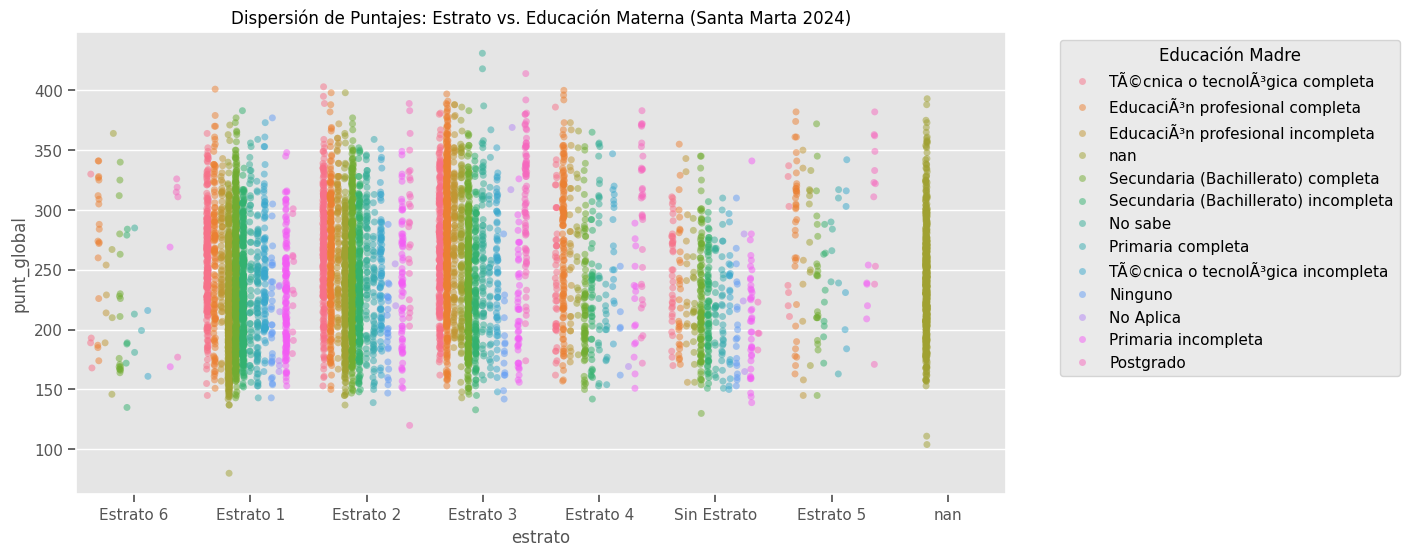

In [10]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=df_sm[df_sm['periodo'] == '20242'], x='estrato', y='punt_global', hue='edu_madre', dodge=True, alpha=0.5)
plt.title('Dispersión de Puntajes: Estrato vs. Educación Materna (Santa Marta 2024)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Educación Madre')
plt.show()

1. Interpretación: El "Muro" Socioeconómico en Santa Marta
Este gráfico muestra cómo se distribuye cada estudiante individualmente. Aquí la interpretación para el Plan Decenal:

El Peso de la Herencia: Observa que en el Estrato 1, la gran masa de puntos (estudiantes) está concentrada por debajo de los 250 puntos. Los puntos que logran subir (los "outliers") suelen tener colores asociados a madres con educación superior. Esto confirma que el capital cultural del hogar pesa más que la infraestructura del colegio.

Techo de Cristal en Estratos Bajos: Hay un límite físico visible. Muy pocos estudiantes de Estrato 1 o 2 logran superar los 350 puntos. La política pública debe enfocarse en esos "casos de éxito" para entender qué están haciendo bien y replicarlo.

La Inequidad Vertical: Compara la "columna" del Estrato 1 con la del Estrato 6 (o los más altos). El Estrato 6 es una columna mucho más delgada pero mucho más alta. En Santa Marta, nacer en Estrato 6 casi garantiza estar por encima del promedio distrital, mientras que en Estrato 1 es una lotería.

In [11]:
# Preparar datos para el radar (Promedios por área y naturaleza)
areas = ['punt_matematicas', 'punt_lectura', 'punt_ciencias', 'punt_sociales', 'punt_ingles']
df_radar = df_sm[df_sm['periodo'] == '20242'].groupby('cole_naturaleza')[areas].mean().reset_index()

# Aquí usarías una librería como plotly o un plot polar de matplotlib

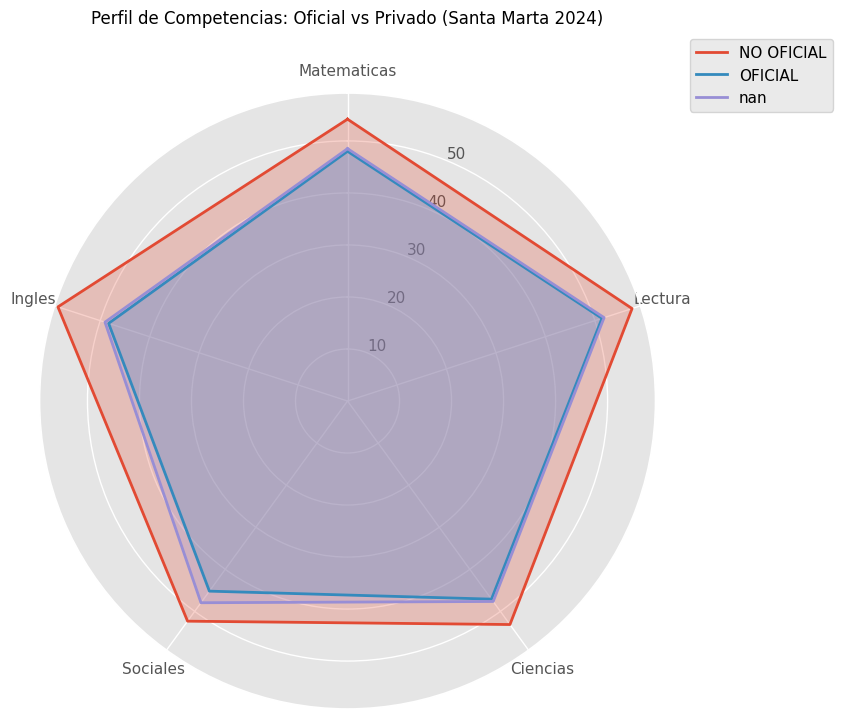

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparar los datos
areas = ['punt_matematicas', 'punt_lectura', 'punt_ciencias', 'punt_sociales', 'punt_ingles']
df_radar = df_sm[df_sm['periodo'] == '20242'].groupby('cole_naturaleza')[areas].mean().reset_index()

# 2. Configuración del gráfico de radar
labels = [a.replace('punt_', '').capitalize() for a in areas]
num_vars = len(labels)

# Ángulos para cada eje
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Cerrar el círculo

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in df_radar.iterrows():
    values = row[areas].values.flatten().tolist()
    values += values[:1] # Cerrar el círculo
    ax.plot(angles, values, linewidth=2, label=row['cole_naturaleza'])
    ax.fill(angles, values, alpha=0.25)

# Arreglar etiquetas
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title('Perfil de Competencias: Oficial vs Privado (Santa Marta 2024)', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

1. Interpretación del Radar: "El Perfil de la Brecha"
El gráfico de radar es revelador porque no solo nos dice quién saca mejor puntaje, sino en qué son mejores.

Dominio Uniforme: Observa que la figura del sector "NO OFICIAL" (rojo) envuelve completamente a la del sector "OFICIAL" (azul). Esto indica que la superioridad del sector privado en Santa Marta es sistémica: son mejores en todas las áreas evaluadas sin excepción.

La Debilidad en Inglés: Mira el eje de Inglés. Es donde la distancia entre las dos líneas es más pronunciada. Para Santa Marta, como Distrito Turístico, esto es una señal de alerta de política pública: el sistema oficial no está preparando a los jóvenes para la principal vocación económica de su propia ciudad.

Equilibrio en el Sector Oficial: La línea azul es casi un pentágono regular, lo que indica que el sector oficial es equilibrado (no es mucho mejor en matemáticas que en sociales), pero ese equilibrio está en un nivel de desempeño bajo (cerca de los 40-45 puntos).

Lectura y Matemáticas: Son las áreas donde el sector privado saca mayor ventaja competitiva. Esto suele estar ligado a la intensidad horaria y a los recursos pedagógicos (bibliotecas y laboratorios).